In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, json, shutil, random
from math import ceil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, optimizers
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.model_selection import train_test_split

In [ ]:
RAW_ROOT = "/content/drive/MyDrive/Eye Retinal Scans"

SPLIT_ROOT = "/content/retina_dataset_split"
TRAIN_DIR = os.path.join(SPLIT_ROOT, "train")
VAL_DIR   = os.path.join(SPLIT_ROOT, "val")

TEST_SIZE = 0.20
RANDOM_STATE = 42

MODEL_NAME = "retina_efficientnetb0"
OUT_DIR = os.path.join("/content", MODEL_NAME)
os.makedirs(OUT_DIR, exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_TOP = 6
EPOCHS_FINE = 6
LR_TOP = 1e-4
LR_FINE = 1e-5
DROP_RATE = 0.3
NUM_CLASSES = 4

In [ ]:
import glob
from pathlib import Path

if not os.path.exists(RAW_ROOT):
    raise FileNotFoundError(f"RAW_ROOT not found: {RAW_ROOT}")

classes = sorted([d.name for d in Path(RAW_ROOT).iterdir() if d.is_dir()])
if len(classes) == 0:
    raise SystemExit("No class subfolders found under RAW_ROOT. Each class should be a subfolder.")

print("Found classes:", classes)

def ensure_empty_dir(d):
    if os.path.exists(d):
        print("Cleaning existing folder:", d)
        for root, dirs, files in os.walk(d, topdown=False):
            for name in files:
                os.remove(os.path.join(root, name))
            for name in dirs:
                shutil.rmtree(os.path.join(root, name))
    os.makedirs(d, exist_ok=True)

ensure_empty_dir(SPLIT_ROOT)
for part in ("train","val"):
    for cls in classes:
        os.makedirs(os.path.join(SPLIT_ROOT, part, cls), exist_ok=True)

image_exts = (".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp")
total_counts = {}
for cls in classes:
    cls_path = os.path.join(RAW_ROOT, cls)
    files = [str(p) for p in Path(cls_path).glob("*") if p.suffix.lower() in image_exts]
    files = sorted(files)
    total_counts[cls] = len(files)
    if len(files) == 0:
        print(f"Warning: no images found for class {cls} at {cls_path}")
    train_files, val_files = train_test_split(files, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True)
    print(f"Class '{cls}': {len(train_files)} train, {len(val_files)} val (total {len(files)})")

    for src in train_files:
        dst = os.path.join(SPLIT_ROOT, "train", cls, os.path.basename(src))
        shutil.copy2(src, dst)
    for src in val_files:
        dst = os.path.join(SPLIT_ROOT, "val", cls, os.path.basename(src))
        shutil.copy2(src, dst)

print("\nFinal dataset stats in split folder:")
for part in ("train","val"):
    print("->", part)
    for cls in classes:
        cnt = len(list(Path(SPLIT_ROOT, part, cls).glob("*")))
        print(f"   {cls}: {cnt}")

Found classes: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Class 'cataract': 830 train, 208 val (total 1038)
Class 'diabetic_retinopathy': 878 train, 220 val (total 1098)
Class 'glaucoma': 805 train, 202 val (total 1007)
Class 'normal': 859 train, 215 val (total 1074)

Final dataset stats in split folder:
-> train
   cataract: 830
   diabetic_retinopathy: 878
   glaucoma: 805
   normal: 859
-> val
   cataract: 208
   diabetic_retinopathy: 220
   glaucoma: 202
   normal: 215


In [ ]:
train_aug = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=15,
    width_shift_range=0.06,
    height_shift_range=0.06,
    zoom_range=0.08,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15),
    fill_mode="nearest"
)
val_aug = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

train_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_aug.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

steps_per_epoch = len(train_gen)
validation_steps = len(val_gen)
print("steps_per_epoch:", steps_per_epoch, "validation_steps:", validation_steps)

index_to_label = {v:k for k,v in train_gen.class_indices.items()}
class_labels = [index_to_label[i] for i in range(len(index_to_label))]
print("class_labels (index->label):", index_to_label)

Found 3372 images belonging to 4 classes.
Found 845 images belonging to 4 classes.
steps_per_epoch: 211 validation_steps: 53
class_labels (index->label): {0: 'cataract', 1: 'diabetic_retinopathy', 2: 'glaucoma', 3: 'normal'}


In [ ]:
def build_effnetb0(input_size=(224,224,3), num_classes=4, drop_rate=0.3):
    inputs = Input(shape=input_size, name="input_image")
    base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)

    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dropout(drop_rate, name="dropout_top")(x)
    x = Dense(256, activation="relu", name="dense_top")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation="softmax", name="predictions")(x)
    model = Model(inputs=inputs, outputs=outputs, name="mobileNetV2_retinal")
    return model, base

model, base_model = build_effnetb0(input_size=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), num_classes=NUM_CLASSES, drop_rate=DROP_RATE)
model.compile(optimizer=optimizers.Adam(LR_TOP),
              loss="sparse_categorical_crossentropy",
              metrics=["sparse_categorical_accuracy"]
             )
model.summary()

/tmp/ipython-input-1849890845.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=inputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobileNetV2_retinal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Training the Model (before fine tuning)
history_top = model.fit(
    train_gen,
    epochs=EPOCHS_TOP,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - loss: 1.1240 - sparse_categorical_accuracy: 0.5154 - val_loss: 0.7311 - val_sparse_categorical_accuracy: 0.6888
Epoch 2/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 206s 977ms/step - loss: 0.6270 - sparse_categorical_accuracy: 0.7456 - val_loss: 0.6146 - val_sparse_categorical_accuracy: 0.7479
Epoch 3/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 263s 980ms/step - loss: 0.5731 - sparse_categorical_accuracy: 0.7639 - val_loss: 0.5581 - val_sparse_categorical_accuracy: 0.7787
Epoch 4/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - loss: 0.5246 - sparse_categorical_accuracy: 0.8009 - val_loss: 0.5618 - val_sparse_categorical_accuracy: 0.7621
Epoch 5/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 207s 983ms/step - loss: 0.5164 - sparse_categorical_accuracy: 0.7875 - val_loss: 0.5530 - val_sparse_categorical_accuracy: 0.7657
Epoch 6/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 211s 1000ms/step - loss: 0.4826 - sparse_categorical_accuracy: 0.8240 - val_loss: 0.4998 - val_sparse_categorical_accuracy

In [10]:
N_unfreeze = 30
for layer in base_model.layers[-N_unfreeze:]:
    layer.trainable = True

model.compile(optimizer=optimizers.Adam(LR_FINE),
              loss="sparse_categorical_crossentropy",
              metrics=["sparse_categorical_accuracy"])

# Training the model (After fine tuning)
history_fine = model.fit(
    train_gen,
    epochs=EPOCHS_TOP,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
)

Epoch 1/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - loss: 1.0542 - sparse_categorical_accuracy: 0.6217 - val_loss: 0.5135 - val_sparse_categorical_accuracy: 0.8024
Epoch 2/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - loss: 0.5956 - sparse_categorical_accuracy: 0.7567 - val_loss: 0.4768 - val_sparse_categorical_accuracy: 0.8225
Epoch 3/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - loss: 0.5737 - sparse_categorical_accuracy: 0.7749 - val_loss: 0.4508 - val_sparse_categorical_accuracy: 0.8320
Epoch 4/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - loss: 0.4998 - sparse_categorical_accuracy: 0.8135 - val_loss: 0.4332 - val_sparse_categorical_accuracy: 0.8379
Epoch 5/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - loss: 0.4841 - sparse_categorical_accuracy: 0.8129 - val_loss: 0.4245 - val_sparse_categorical_accuracy: 0.8320
Epoch 6/6
211/211 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - loss: 0.4272 - sparse_categorical_accuracy: 0.8408 - val_loss: 0.3883 - val_sparse_categorical_accuracy: 0.8568


In [14]:
# Evaluate on validation set
def combine_hist(h1, h2):
    out = {}
    for k in set(list(h1.history.keys()) + list(h2.history.keys())):
        out[k] = (h1.history.get(k, []) + h2.history.get(k, []))
    return out

combined_hist = combine_hist(history_top, history_fine)
# Save history to disk
with open(os.path.join(OUT_DIR, "history_combined.json"), "w") as f:
    json.dump(combined_hist, f)

val_metrics = model.evaluate(val_gen, verbose=1)
print("Validation metrics (loss, acc, auc):", val_metrics)

53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 631ms/step - loss: 0.3132 - sparse_categorical_accuracy: 0.8848
Validation metrics (loss, acc, auc): [0.38828107714653015, 0.8568047285079956]


In [ ]:
keras_file = os.path.join(OUT_DIR, f"{MODEL_NAME}.keras")
h5_file = os.path.join(OUT_DIR, f"{MODEL_NAME}.h5")
saved_dir = os.path.join(OUT_DIR, "exported_for_serving")

try:
    model.save(keras_file, include_optimizer=False)
    print("Saved Keras single-file:", keras_file)
except Exception as e:
    print("Saving .keras failed:", e)

try:
    model.save(h5_file, include_optimizer=False)
    print("Saved HDF5:", h5_file)
except Exception as e:
    print("HDF5 save failed (ok if .keras exists):", e)

try:
    if hasattr(model, "export"):
        model.export(saved_dir)
        print("Saved model.export to:", saved_dir)
    else:
        tf.saved_model.save(model, saved_dir)
        print("Saved tf.saved_model to:", saved_dir)
except Exception as e:
    print("SavedModel export failed:", e)

meta = {
    "input_size": [IMAGE_SIZE[0], IMAGE_SIZE[1]],
    "preprocessing": "mobilenet_preprocess",
    "class_labels": class_labels,
    "last_conv_layer": "Conv_1"
}
with open(os.path.join(OUT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f)

shutil.make_archive(OUT_DIR + "_bundle", 'zip', OUT_DIR)
print("Model bundle saved to:", OUT_DIR)

Saved Keras single-file: /content/retina_efficientnetb0/retina_efficientnetb0.keras
Saved HDF5: /content/retina_efficientnetb0/retina_efficientnetb0.h5
Saved artifact at '/content/retina_efficientnetb0/exported_for_serving'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136824381891088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136824381892240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136824381892624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136824381891856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136824381890896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136824381892432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136824381892816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136824381893584: TensorSpec(shape=(), 

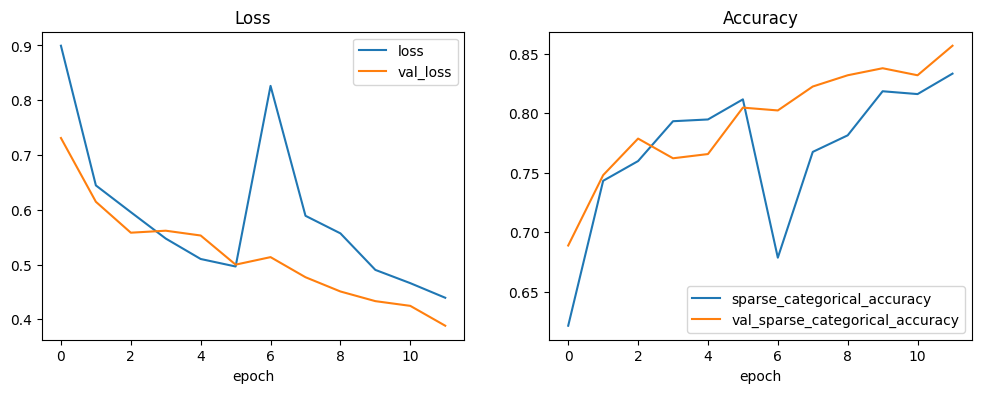

53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 633ms/step


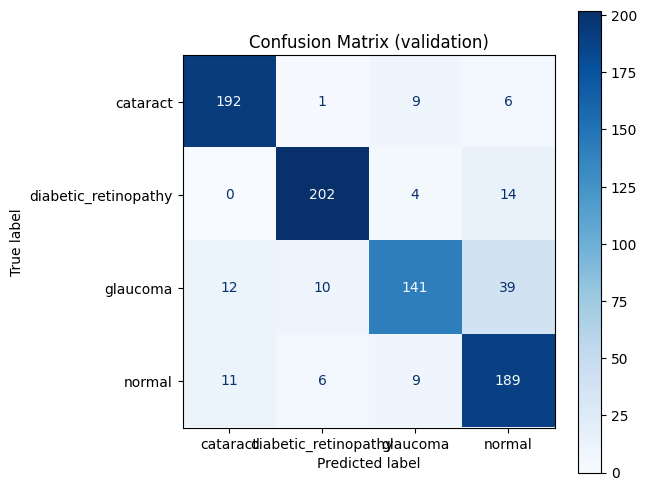

                      precision    recall  f1-score   support

            cataract     0.8930    0.9231    0.9078       208
diabetic_retinopathy     0.9224    0.9182    0.9203       220
            glaucoma     0.8650    0.6980    0.7726       202
              normal     0.7621    0.8791    0.8164       215

            accuracy                         0.8568       845
           macro avg     0.8606    0.8546    0.8543       845
        weighted avg     0.8607    0.8568    0.8555       845



In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

hist = combined_hist
# accuracy vs loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist.get("loss", []), label="loss")
if hist.get("val_loss"):
    plt.plot(hist.get("val_loss"), label="val_loss")
plt.legend(); plt.title("Loss"); plt.xlabel("epoch")

plt.subplot(1,2,2)
for key in ("sparse_categorical_accuracy","accuracy","acc"):
    if key in hist:
        plt.plot(hist[key], label=key)
        if "val_" + key in hist:
            plt.plot(hist["val_" + key], label="val_"+key)
        break
plt.legend(); plt.title("Accuracy"); plt.xlabel("epoch")
plt.show()

# Confusion matrix on val set
y_true = val_gen.classes
steps = len(val_gen)
y_score = model.predict(val_gen, steps=steps, verbose=1)
if y_score.ndim == 2 and y_score.shape[1] == 1:
    y_pred = (y_score[:,0] >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_score, axis=1)

cm = confusion_matrix(y_true, y_pred)
labels = [class_labels[i] for i in range(len(class_labels))]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix (validation)")
plt.show()

# classification report
print(classification_report(y_true, y_pred, target_names=labels, digits=4))